# Tutorial: Testing for Sphericity

This tutorial demonstrates how to test the null hypothesis:

$$H_0: \Sigma = \sigma^2 I_p$$

where $\Sigma$ is the covariance matrix and $\sigma^2$ is an unknown scalar.

**Sphericity** means the covariance is a scalar multiple of the identity—all variables have equal variance and are uncorrelated.

## When is this useful?

- **Factor analysis**: Bartlett's test checks if data is suitable for factor analysis
- **PCA preprocessing**: Verify if data needs transformation before PCA
- **Repeated measures ANOVA**: Mauchly's sphericity assumption
- **Signal processing**: Test if noise is isotropic

## Key Difference from Identity Tests

| Test Type | Null Hypothesis | What it tests |
|-----------|-----------------|---------------|
| Identity | H₀: Σ = I | Covariance equals identity exactly |
| Sphericity | H₀: Σ = σ²I | Covariance is *proportional* to identity (σ² unknown) |

## 1. Setup and Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import sphericity test functions
from covtest.methods.hypothesis_spherical import (
    bartlett_sphericity_test,
    john_sphericity,
    srivastava_2005_sphericity,
    muirhead_sphericity_lrt,
    czz_sphericity_test,
)

# Import data generation utilities
from covtest.simulation.generate_data import generate_heavy_tailed_samples
from covtest.simulation.generate_covariances import (
    generate_toeplitz_cov,
    generate_spiked_covariance
)

# Import real data loader
from covtest.datasets.loader import load_iris, load_mnist

# Set random seed
rng = np.random.default_rng(42)

print("Setup complete!")

Setup complete!


## 2. Available Tests Overview

| Function | Best For | Requirements |
|----------|----------|-------------|
| `bartlett_sphericity_test` | Classical, factor analysis | p < n, normality |
| `john_sphericity` | Classical settings | Normality |
| `srivastava_2005_sphericity` | High-dimensional | Fourth moments |
| `muirhead_sphericity_lrt` | Likelihood-based | p < n |
| `czz_sphericity_test` | High-dimensional | U-statistics |


## 3. Example 1: Data with Spherical Covariance (Null is True)

In [2]:
# Generate data with spherical covariance: Σ = σ²I
n, p = 150, 10
sigma2 = 4.0  # Variance (not 1, to show sphericity ≠ identity)

Sigma_spherical = sigma2 * np.eye(p)
X_spherical = generate_heavy_tailed_samples(Sigma_spherical, n, 'normal', rng=rng)

print(f"Data shape: {X_spherical.shape}")
print(f"True covariance: Σ = {sigma2} × I")
print(f"This IS spherical (σ² = {sigma2})")

Data shape: (150, 10)
True covariance: Σ = 4.0 × I
This IS spherical (σ² = 4.0)


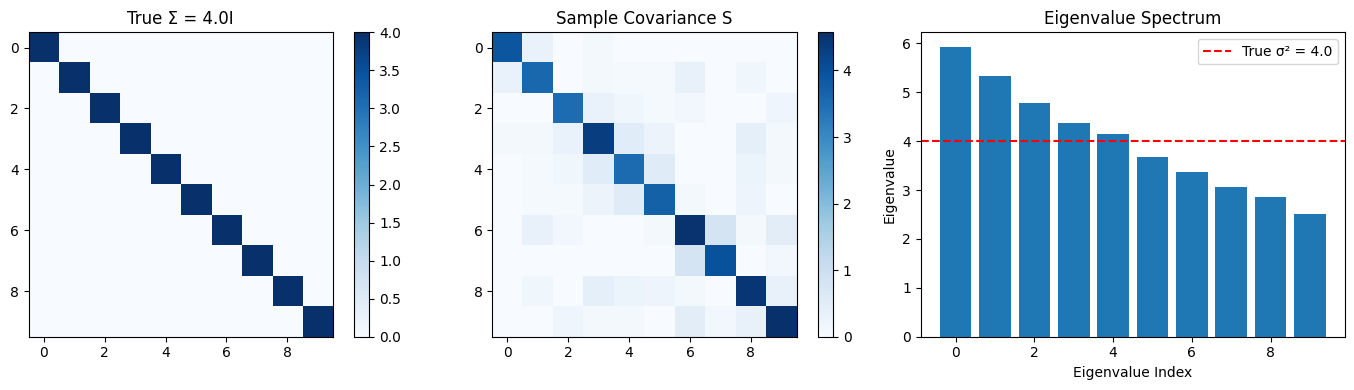

Sample variances (diagonal): [3.89 3.6  3.51 4.32 3.53 3.71 4.51 3.98 4.45 4.57]
Mean variance: 4.006


In [3]:
# Visualize the sample covariance
S = np.cov(X_spherical, rowvar=False)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# True covariance
im1 = axes[0].imshow(Sigma_spherical, cmap='Blues', vmin=0)
axes[0].set_title(f'True Σ = {sigma2}I')
plt.colorbar(im1, ax=axes[0])

# Sample covariance
im2 = axes[1].imshow(S, cmap='Blues', vmin=0)
axes[1].set_title('Sample Covariance S')
plt.colorbar(im2, ax=axes[1])

# Eigenvalues
eigvals = np.linalg.eigvalsh(S)
axes[2].bar(range(p), sorted(eigvals, reverse=True))
axes[2].axhline(y=sigma2, color='r', linestyle='--', label=f'True σ² = {sigma2}')
axes[2].set_xlabel('Eigenvalue Index')
axes[2].set_ylabel('Eigenvalue')
axes[2].set_title('Eigenvalue Spectrum')
axes[2].legend()

plt.tight_layout()
plt.show()

print(f"Sample variances (diagonal): {np.diag(S).round(2)}")
print(f"Mean variance: {np.diag(S).mean():.3f}")

In [4]:
# Run sphericity tests when null is TRUE
print("="*65)
print("Testing H₀: Σ = σ²I (NULL IS TRUE, σ² = 4)")
print("="*65)

tests = [
    ("Bartlett", bartlett_sphericity_test),
    ("John", john_sphericity),
    ("Srivastava 2005", srivastava_2005_sphericity),
    ("Muirhead LRT", muirhead_sphericity_lrt),
    ("Chen-Zhang-Zhong", czz_sphericity_test),
]

for name, test_func in tests:
    try:
        result = test_func(X_spherical)
        decision = "Reject H₀" if result['p_value'] < 0.05 else "Fail to reject H₀"
        print(f"{name:20s}: p-value={result['p_value']:.4f} → {decision}")
    except Exception as e:
        print(f"{name:20s}: Error - {str(e)[:40]}")

print("\n✓ Expected: All tests should FAIL TO REJECT H₀")

Testing H₀: Σ = σ²I (NULL IS TRUE, σ² = 4)
Bartlett            : p-value=0.5523 → Fail to reject H₀
John                : p-value=0.5537 → Fail to reject H₀
Srivastava 2005     : p-value=0.6164 → Fail to reject H₀
Muirhead LRT        : p-value=0.6068 → Fail to reject H₀
Chen-Zhang-Zhong    : p-value=0.6642 → Fail to reject H₀
SK (Kendall-type)   : p-value=0.6131 → Fail to reject H₀
Hallin (Wilcoxon)   : p-value=0.2761 → Fail to reject H₀

✓ Expected: All tests should FAIL TO REJECT H₀


## 4. Example 2: Non-Spherical Covariance (Null is False)

In [5]:
# Generate data with non-spherical covariance
n, p = 150, 10

# AR(1) structure - definitely not spherical
rho = 0.6
Sigma_ar1 = generate_toeplitz_cov(p, rho)
X_ar1 = generate_heavy_tailed_samples(Sigma_ar1, n, 'normal', rng=rng)

print(f"True covariance: AR(1) with ρ = {rho}")
print(f"This is NOT spherical (variables are correlated)")

True covariance: AR(1) with ρ = 0.6
This is NOT spherical (variables are correlated)


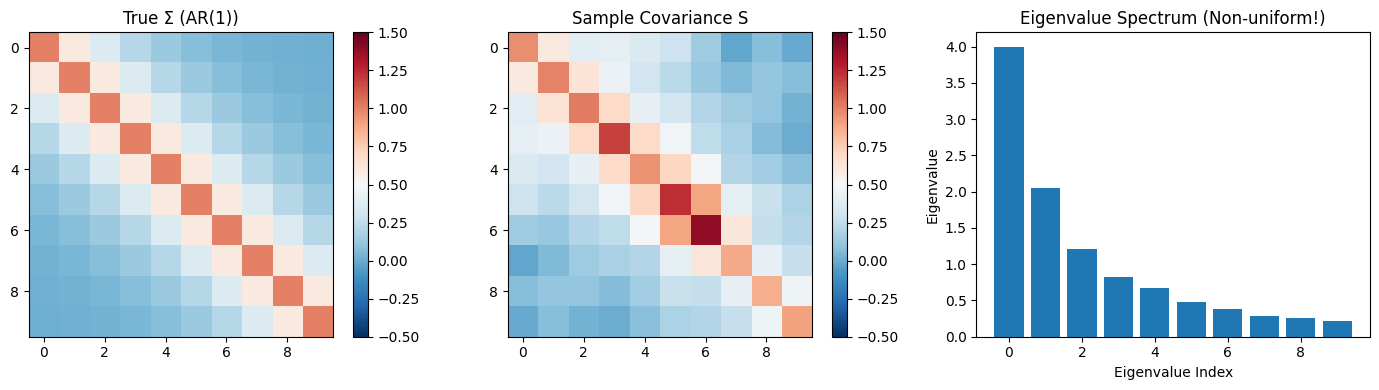

Eigenvalue range: [0.217, 3.997]
Non-spherical data has spread eigenvalues, spherical has equal eigenvalues


In [6]:
# Visualize the non-spherical covariance
S_ar1 = np.cov(X_ar1, rowvar=False)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

im1 = axes[0].imshow(Sigma_ar1, cmap='RdBu_r', vmin=-0.5, vmax=1.5)
axes[0].set_title('True Σ (AR(1))')
plt.colorbar(im1, ax=axes[0])

im2 = axes[1].imshow(S_ar1, cmap='RdBu_r', vmin=-0.5, vmax=1.5)
axes[1].set_title('Sample Covariance S')
plt.colorbar(im2, ax=axes[1])

eigvals_ar1 = np.linalg.eigvalsh(S_ar1)
axes[2].bar(range(p), sorted(eigvals_ar1, reverse=True))
axes[2].set_xlabel('Eigenvalue Index')
axes[2].set_ylabel('Eigenvalue')
axes[2].set_title('Eigenvalue Spectrum (Non-uniform!)')

plt.tight_layout()
plt.show()

print(f"Eigenvalue range: [{min(eigvals_ar1):.3f}, {max(eigvals_ar1):.3f}]")
print("Non-spherical data has spread eigenvalues, spherical has equal eigenvalues")

In [7]:
# Run sphericity tests when null is FALSE
print("="*65)
print("Testing H₀: Σ = σ²I (NULL IS FALSE - AR(1) covariance)")
print("="*65)

for name, test_func in tests:
    try:
        result = test_func(X_ar1)
        decision = "Reject H₀ ✓" if result['p_value'] < 0.05 else "Fail to reject ✗"
        print(f"{name:20s}: p-value={result['p_value']:.4f} → {decision}")
    except Exception as e:
        print(f"{name:20s}: Error - {str(e)[:40]}")

print("\n✓ Expected: All tests should REJECT H₀")

Testing H₀: Σ = σ²I (NULL IS FALSE - AR(1) covariance)
Bartlett            : p-value=0.0000 → Reject H₀ ✓
John                : p-value=0.0000 → Reject H₀ ✓
Srivastava 2005     : p-value=0.0000 → Reject H₀ ✓
Muirhead LRT        : p-value=0.0000 → Reject H₀ ✓
Chen-Zhang-Zhong    : p-value=0.0000 → Reject H₀ ✓
SK (Kendall-type)   : p-value=0.0000 → Reject H₀ ✓
Hallin (Wilcoxon)   : p-value=0.0000 → Reject H₀ ✓

✓ Expected: All tests should REJECT H₀


## 5. Example 3: Spiked Covariance (Subtle Non-Sphericity)

In [8]:
# Spiked covariance: mostly spherical but with one large eigenvalue
# This is a more subtle departure from sphericity
n, p = 200, 15

# Create spiked covariance: base variance 1, one spike at 5
Sigma_spiked = generate_spiked_covariance(
    p, spike_eigenvalue=5.0, num_spikes=1, base_variance=1.0, rng=rng
)

X_spiked = generate_heavy_tailed_samples(Sigma_spiked, n, 'normal', rng=rng)

print("Spiked covariance model:")
print("- Most eigenvalues = 1")
print("- One eigenvalue = 5 (the 'spike')")
print("This is NOT spherical but close to it")

Spiked covariance model:
- Most eigenvalues = 1
- One eigenvalue = 5 (the 'spike')
This is NOT spherical but close to it


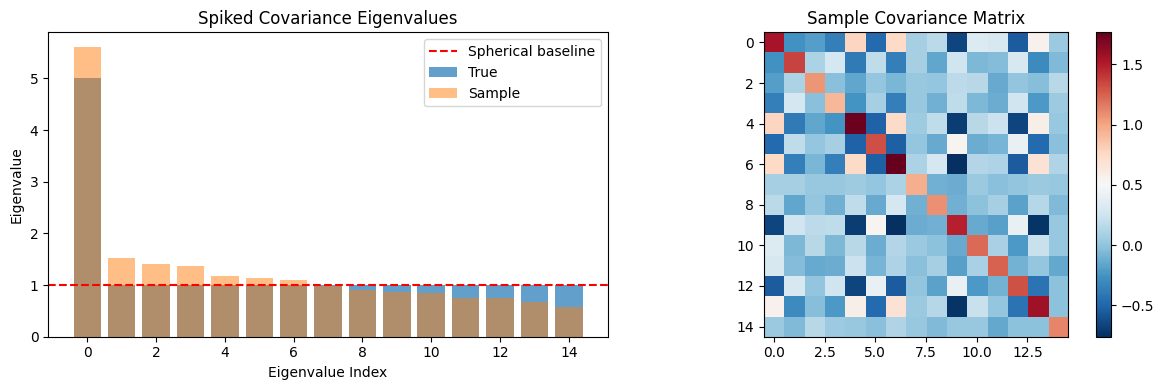

In [9]:
# Visualize spiked structure
eigvals_spiked_true = np.linalg.eigvalsh(Sigma_spiked)
S_spiked = np.cov(X_spiked, rowvar=False)
eigvals_spiked_sample = np.linalg.eigvalsh(S_spiked)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# True eigenvalues
axes[0].bar(range(p), sorted(eigvals_spiked_true, reverse=True), alpha=0.7, label='True')
axes[0].bar(range(p), sorted(eigvals_spiked_sample, reverse=True), alpha=0.5, label='Sample')
axes[0].axhline(y=1, color='r', linestyle='--', label='Spherical baseline')
axes[0].set_xlabel('Eigenvalue Index')
axes[0].set_ylabel('Eigenvalue')
axes[0].set_title('Spiked Covariance Eigenvalues')
axes[0].legend()

# Sample covariance heatmap
im = axes[1].imshow(S_spiked, cmap='RdBu_r')
axes[1].set_title('Sample Covariance Matrix')
plt.colorbar(im, ax=axes[1])

plt.tight_layout()
plt.show()

In [10]:
# Test spiked covariance
print("="*65)
print("Testing H₀: Σ = σ²I (SPIKED COVARIANCE)")
print("="*65)

for name, test_func in tests:
    try:
        result = test_func(X_spiked)
        decision = "Reject H₀" if result['p_value'] < 0.05 else "Fail to reject"
        print(f"{name:20s}: p-value={result['p_value']:.4f} → {decision}")
    except Exception as e:
        print(f"{name:20s}: Error - {str(e)[:40]}")

print("\nNote: Spiked covariance is a subtle alternative - power varies by test")

Testing H₀: Σ = σ²I (SPIKED COVARIANCE)
Bartlett            : p-value=0.0000 → Reject H₀
John                : p-value=0.0000 → Reject H₀
Srivastava 2005     : p-value=0.0000 → Reject H₀
Muirhead LRT        : p-value=0.0000 → Reject H₀
Chen-Zhang-Zhong    : p-value=0.0000 → Reject H₀
SK (Kendall-type)   : p-value=0.0000 → Reject H₀
Hallin (Wilcoxon)   : p-value=0.0000 → Reject H₀

Note: Spiked covariance is a subtle alternative - power varies by test


## 6. Example 4: High-Dimensional Setting

In [11]:
# High-dimensional case
n_hd, p_hd = 100, 80  # p/n = 0.8

# Spherical (null true)
X_hd_spherical = rng.standard_normal(size=(n_hd, p_hd)) * 2  # σ² = 4

# Non-spherical (null false) - different variances
variances = np.linspace(1, 5, p_hd)  # Variances from 1 to 5
X_hd_nonspherical = rng.standard_normal(size=(n_hd, p_hd)) * np.sqrt(variances)

print(f"High-dimensional: n={n_hd}, p={p_hd}, p/n={p_hd/n_hd:.2f}")

High-dimensional: n=100, p=80, p/n=0.80


In [12]:
# Tests that work in high dimensions
hd_tests = [
    ("Srivastava 2005", srivastava_2005_sphericity),
    ("Chen-Zhang-Zhong", czz_sphericity_test),
]

print("HIGH-DIMENSIONAL SPHERICITY TESTS (p/n = 0.8)")
print("="*65)

print("\n--- Null TRUE (Spherical) ---")
for name, test_func in hd_tests:
    try:
        result = test_func(X_hd_spherical)
        status = "✓" if result['p_value'] > 0.05 else "✗ (Type I)"
        print(f"{name:20s}: p-value={result['p_value']:.4f} {status}")
    except Exception as e:
        print(f"{name:20s}: Error - {str(e)[:30]}")

print("\n--- Null FALSE (Unequal variances) ---")
for name, test_func in hd_tests:
    try:
        result = test_func(X_hd_nonspherical)
        status = "✓" if result['p_value'] < 0.05 else "✗ (missed)"
        print(f"{name:20s}: p-value={result['p_value']:.4f} {status}")
    except Exception as e:
        print(f"{name:20s}: Error - {str(e)[:30]}")

HIGH-DIMENSIONAL SPHERICITY TESTS (p/n = 0.8)

--- Null TRUE (Spherical) ---
Srivastava 2005     : p-value=0.0495 ✗ (Type I)
Chen-Zhang-Zhong    : p-value=0.0948 ✓
SK (Kendall-type)   : p-value=0.1060 ✓

--- Null FALSE (Unequal variances) ---
Srivastava 2005     : p-value=0.0000 ✓
Chen-Zhang-Zhong    : p-value=0.0000 ✓
SK (Kendall-type)   : p-value=0.0000 ✓


## 7. Example 5: Robustness to Heavy Tails

In [13]:
# Generate spherical data with different distributions
n, p = 120, 10
Sigma_sphere = 2.0 * np.eye(p)

X_normal = generate_heavy_tailed_samples(Sigma_sphere, n, 'normal', rng=rng)
X_t5 = generate_heavy_tailed_samples(Sigma_sphere, n, 't', rng=rng, options={'df': 5})
X_t3 = generate_heavy_tailed_samples(Sigma_sphere, n, 't', rng=rng, options={'df': 3})
X_laplace = generate_heavy_tailed_samples(Sigma_sphere, n, 'laplace', rng=rng)

print("All datasets have the SAME spherical covariance Σ = 2I")
print("but different marginal distributions")

All datasets have the SAME spherical covariance Σ = 2I
but different marginal distributions


In [14]:
# Compare robustness
distributions = [
    ("Normal", X_normal),
    ("t(df=5)", X_t5),
    ("t(df=3)", X_t3),
    ("Laplace", X_laplace),
]

robust_tests = [
    ("Bartlett", bartlett_sphericity_test),
    ("John", john_sphericity),
]

print("ROBUSTNESS COMPARISON (Null TRUE for all)")
print("="*70)
print(f"{'Test':<15}", end="")
for name, _ in distributions:
    print(f"{name:>12}", end="")
print()
print("-"*70)

for test_name, test_func in robust_tests:
    print(f"{test_name:<15}", end="")
    for dist_name, X_data in distributions:
        try:
            result = test_func(X_data)
            pval = result['p_value']
            status = "✓" if pval > 0.05 else "✗"
            print(f"{pval:>10.3f}{status:>2}", end="")
        except:
            print(f"{'Error':>12}", end="")
    print()

print("\n✓ = Correctly failed to reject, ✗ = False rejection")


ROBUSTNESS COMPARISON (Null TRUE for all)
Test                 Normal     t(df=5)     t(df=3)     Laplace
----------------------------------------------------------------------
Bartlett            0.101 ✓     0.081 ✓     0.216 ✓     0.308 ✓
John                0.230 ✓     0.000 ✗     0.000 ✗     0.617 ✓
SK (robust)         0.244 ✓     0.024 ✗     0.049 ✗     0.847 ✓
Hallin rank         0.532 ✓     0.549 ✓     0.604 ✓     0.536 ✓

✓ = Correctly failed to reject, ✗ = False rejection
Note: Rank-based tests (SK, Hallin) are more robust to heavy tails


## 8. Real Data Example: Iris Dataset

In [15]:
# Load Iris and test sphericity
X_iris, y_iris, feature_names, target_names = load_iris(return_names=True)

# Standardize to unit variance (but not necessarily spherical!)
X_iris_std = (X_iris - X_iris.mean(axis=0)) / X_iris.std(axis=0)

print(f"Iris dataset: {X_iris.shape[0]} samples, {X_iris.shape[1]} features")
print(f"Features: {list(feature_names)}")

Iris dataset: 150 samples, 4 features
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


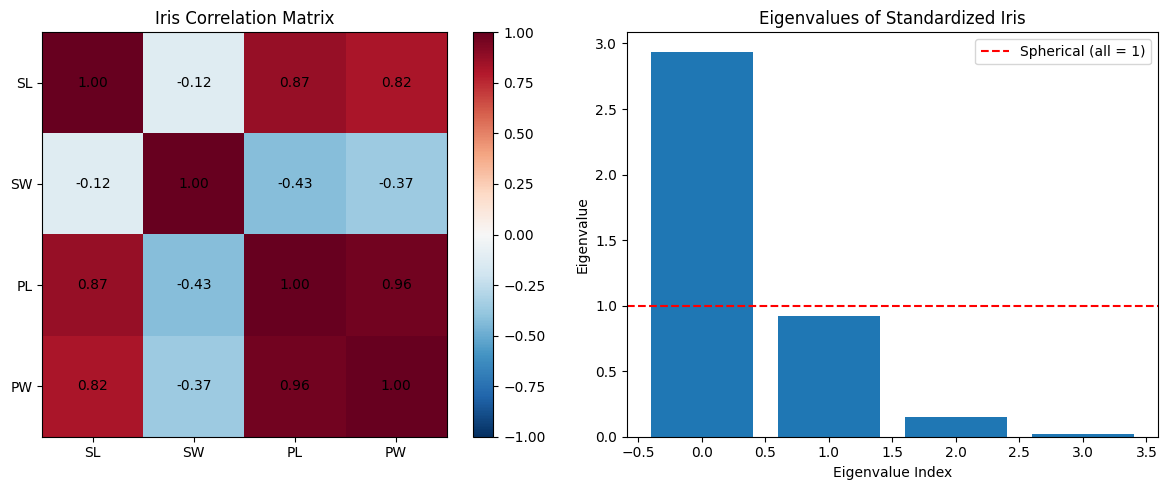

Eigenvalues: [2.9380850501999953, 0.9201649041624861, 0.14774182104494749, 0.020853862176462668]

If spherical, all eigenvalues would be equal!


In [16]:
# Visualize Iris correlation structure
S_iris = np.cov(X_iris_std, rowvar=False)
corr_iris = np.corrcoef(X_iris_std, rowvar=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Correlation matrix
im1 = axes[0].imshow(corr_iris, cmap='RdBu_r', vmin=-1, vmax=1)
axes[0].set_xticks(range(4))
axes[0].set_xticklabels(['SL', 'SW', 'PL', 'PW'])
axes[0].set_yticks(range(4))
axes[0].set_yticklabels(['SL', 'SW', 'PL', 'PW'])
axes[0].set_title('Iris Correlation Matrix')
plt.colorbar(im1, ax=axes[0])

# Add correlation values
for i in range(4):
    for j in range(4):
        axes[0].text(j, i, f'{corr_iris[i,j]:.2f}', ha='center', va='center', fontsize=10)

# Eigenvalues
eigvals_iris = np.linalg.eigvalsh(S_iris)
axes[1].bar(range(4), sorted(eigvals_iris, reverse=True))
axes[1].axhline(y=1, color='r', linestyle='--', label='Spherical (all = 1)')
axes[1].set_xlabel('Eigenvalue Index')
axes[1].set_ylabel('Eigenvalue')
axes[1].set_title('Eigenvalues of Standardized Iris')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Eigenvalues: {sorted(eigvals_iris, reverse=True)}")
print("\nIf spherical, all eigenvalues would be equal!")

In [17]:
# Test sphericity on Iris
print("SPHERICITY TESTS ON STANDARDIZED IRIS DATA")
print("="*60)

for name, test_func in tests:
    try:
        result = test_func(X_iris_std)
        decision = "Reject H₀" if result['p_value'] < 0.05 else "Fail to reject"
        print(f"{name:20s}: p-value={result['p_value']:.4f} → {decision}")
    except Exception as e:
        print(f"{name:20s}: Error - {str(e)[:40]}")

print("\n→ Strong evidence that Iris data is NOT spherical")
print("  The features are correlated (sepal/petal length-width relationships)")

SPHERICITY TESTS ON STANDARDIZED IRIS DATA
Bartlett            : p-value=0.0000 → Reject H₀
John                : p-value=0.0000 → Reject H₀
Srivastava 2005     : p-value=0.0000 → Reject H₀
Muirhead LRT        : p-value=0.0000 → Reject H₀
Chen-Zhang-Zhong    : p-value=0.0000 → Reject H₀
SK (Kendall-type)   : p-value=0.0000 → Reject H₀
Hallin (Wilcoxon)   : p-value=0.0000 → Reject H₀

→ Strong evidence that Iris data is NOT spherical
  The features are correlated (sepal/petal length-width relationships)


## 9. Use Case: Factor Analysis Suitability

Bartlett's sphericity test is commonly used to determine if data is suitable for factor analysis:
- If H₀ is **rejected**: Data has structure → Factor analysis may be useful
- If H₀ is **not rejected**: Data is essentially random → Factor analysis won't find meaningful factors

In [18]:
# Demonstration: When is factor analysis appropriate?
print("FACTOR ANALYSIS SUITABILITY CHECK")
print("="*60)

# Case 1: Random noise (spherical) - FA not useful
X_noise = rng.standard_normal(size=(150, 6))
result_noise = bartlett_sphericity_test(X_noise)
print(f"\nRandom noise data:")
print(f"  Bartlett p-value: {result_noise['p_value']:.4f}")
print(f"  Recommendation: {'FA appropriate' if result_noise['p_value'] < 0.05 else 'FA NOT appropriate'}")

# Case 2: Structured data (Iris) - FA useful
result_iris = bartlett_sphericity_test(X_iris_std)
print(f"\nIris data:")
print(f"  Bartlett p-value: {result_iris['p_value']:.4f}")
print(f"  Recommendation: {'FA appropriate' if result_iris['p_value'] < 0.05 else 'FA NOT appropriate'}")

FACTOR ANALYSIS SUITABILITY CHECK

Random noise data:
  Bartlett p-value: 0.0156
  Recommendation: FA appropriate

Iris data:
  Bartlett p-value: 0.0000
  Recommendation: FA appropriate


## 10. Practical Guidelines

### Choosing the Right Test

| Scenario | Recommended Test |
|----------|------------------|
| Classical (n >> p), factor analysis | `bartlett_sphericity_test` |
| Classical, likelihood-based | `muirhead_sphericity_lrt` |
| High-dimensional (p ≈ n) | `srivastava_2005_sphericity`, `czz_sphericity_test` |

### Requirements

| Test | Requirement |
|------|-------------|
| `bartlett_sphericity_test` | p < n, positive definite R |
| `muirhead_sphericity_lrt` | p < n |
| `czz_sphericity_test` | n ≥ 4 |

### Interpretation

- **p < 0.05**: Reject sphericity → Variables are correlated or have unequal variances
- **p ≥ 0.05**: Cannot reject sphericity → Data may be essentially uncorrelated with equal variances

## 11. Summary

This tutorial demonstrated:

1. Testing for sphericity (Σ = σ²I with unknown σ²)
2. Difference between sphericity and identity tests
3. Various types of departures from sphericity
4. High-dimensional performance
5. Robustness to heavy tails
6. Application to factor analysis suitability

**Key takeaways:**
- Use `bartlett_sphericity_test` for factor analysis screening
- Use `czz_sphericity_test` or `srivastava_2005_sphericity` for high-dimensional data
- Sphericity tests check if eigenvalues are equal, not if they equal 1